<a href="https://colab.research.google.com/github/Rahma772/Praktikum-Pemodelan-Simulasi-dan-Optimasi/blob/main/Tugas_3_Teknik_Simulasi_PSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Library yang akan digunakan**

In [1]:
import numpy as np
import matplotlib.pyplot as plt



**Menyiapkan Parameter Simulasi Harga Saham**

In [8]:
# Parameter
np.random.seed(42)  # agar hasil konsisten
mu = 0.001          # rata-rata return
sigma = 0.02        # standar deviasi
n_days = 90         # jumlah hari
initial_price = 100 # harga awal
print("=== PARAMETER ===")
print(f"Mean (mu): {mu}")
print(f"Standar deviasi (sigma): {sigma}")
print(f"Jumlah hari: {n_days}")
print(f"Harga awal: {initial_price}")



=== PARAMETER ===
Mean (mu): 0.001
Standar deviasi (sigma): 0.02
Jumlah hari: 90
Harga awal: 100


Berdasarkan parameter yang digunakan, simulasi menggambarkan saham yang memiliki rata-rata kenaikan kecil (0,1% per hari) namun dengan tingkat fluktuasi yang cukup tinggi (2%) selama periode 90 hari, dimulai dari harga 100. Jadi meskipun harga saham cenderung meningkat, pergerakannya akan tidak stabil dan sering naik turun, dimana saham memiliki potensi keuntungan dalam jangka waktu tertentu, tetapi juga mengandung risiko yang cukup tinggi, sehingga pergerakannya tidak bisa diprediksi secara pasti.

**Membuat dan Menampilkan Simulasi Return harian secara acak**

In [9]:
# Simulasi return harian (distribusi normal)
returns = np.random.normal(mu, sigma, n_days)
print("\n=== RETURN HARIAN (10 DATA PERTAMA) ===")
print(returns[:10])




=== RETURN HARIAN (10 DATA PERTAMA) ===
[ 0.01093428 -0.00176529  0.01395377  0.0314606  -0.00368307 -0.00368274
  0.03258426  0.01634869 -0.00838949  0.0118512 ]


Berdasarkan 10 data return harian pertama, saham menunjukkan pergerakan yang tidak stabil dengan kombinasi kenaikan dan penurunan. Namun, pergerakan positif lebih dominan, sehingga dalam jangka pendek terdapat kecenderungan harga meningkat. Jadi, meskipun saham mengalami naik-turun setiap hari, secara keseluruhan berpotensi memberikan keuntungan, tetapi tetap memiliki risiko karena adanya volatilitas.

**Mengubah Return Harian Menjadi Harga Saham Setiap Hari**

In [12]:
prices = [initial_price]

for r in returns:
    new_price = prices[-1] * (1 + r)
    prices.append(new_price)

print("\n=== HARGA SAHAM (10 HARI PERTAMA) ===")
print(prices[:10])


=== HARGA SAHAM (10 HARI PERTAMA) ===
[100, np.float64(101.09342830602246), np.float64(100.91496948997384), np.float64(102.32311384069256), np.float64(105.5422601021335), np.float64(105.15354083465878), np.float64(104.76628777422427), np.float64(108.18001934772228), np.float64(109.94862144402752), np.float64(109.02620883473496)]


Harga saham mengalami pergerakan tidak stabil (naik-turun) setiap hari, tetapi secara keseluruhan menunjukkan tren meningkat dari 100 menjadi sekitar 109 dalam 10 hari. Jadi, saham memiliki potensi keuntungan dalam jangka pendek, namun tetap disertai risiko karena pergerakannya tidak stabil.

**Menampilkan Detail Pergerakan Saham per Hari**

In [13]:
print("\n=== DETAIL 5 HARI PERTAMA ===")
for i in range(5):
    print(f"Hari {i+1}: Return = {returns[i]:.4f}, Harga = {prices[i+1]:.2f}")


=== DETAIL 5 HARI PERTAMA ===
Hari 1: Return = 0.0109, Harga = 101.09
Hari 2: Return = -0.0018, Harga = 100.91
Hari 3: Return = 0.0140, Harga = 102.32
Hari 4: Return = 0.0315, Harga = 105.54
Hari 5: Return = -0.0037, Harga = 105.15


Dalam 5 hari pertama, harga saham mengalami naik-turun (tidak stabil), namun lebih sering mengalami kenaikan dibanding penurunan. Jadi, terdapat kecenderungan tren naik dalam jangka pendek, sehingga saham memiliki potensi keuntungan, meskipun tetap disertai risiko karena pergerakan yang tidak stabil.

**Menghitung dan Menampilkan Tingkat Volatilitas dari Return Harian Saham**

In [14]:
volatilitas = np.std(returns)

print("\n=== VOLATILITAS ===")
print(f"Volatilitas return harian: {volatilitas:.4f}")


=== VOLATILITAS ===
Volatilitas return harian: 0.0186


Volatilitas sebesar 0,0186 (1,86%) menunjukkan bahwa saham memiliki pergerakan yang cukup fluktuatif, sehingga tingkat risikonya relatif tinggi. Jadi, harga saham dapat berubah cukup besar hari, sehingga berpotensi memberikan keuntungan, tetapi juga memiliki risiko yang tidak kecil.

**Menampilkan Grafik Harga Saham Selama 90 Hari**

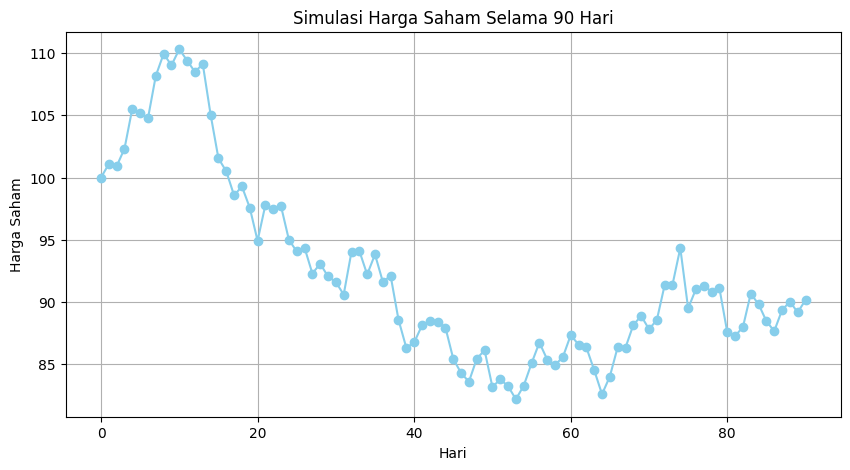

In [31]:
# Plot hasil
plt.figure(figsize=(10,5))
plt.plot(prices, marker='o', color='skyblue')
plt.title('Simulasi Harga Saham Selama 90 Hari')
plt.xlabel('Hari')
plt.ylabel('Harga Saham')
plt.grid()
plt.show()

Berdasarkan grafik diatas menunjukkan bahwa harga saham mengalami fluktuasi yang tinggi selama 90 hari. Meskipun sempat mengalami kenaikan di awal, harga kemudian menurun dan bergerak tidak stabil, sebelum sedikit pulih di akhir periode. Secara keseluruhan, saham memiliki risiko yang tinggi dengan pergerakan yang tidak menentu, dan tidak mampu mempertahankan kenaikan awalnya hingga akhir periode.

**Membuat Histogram dari Return Harian Saham**

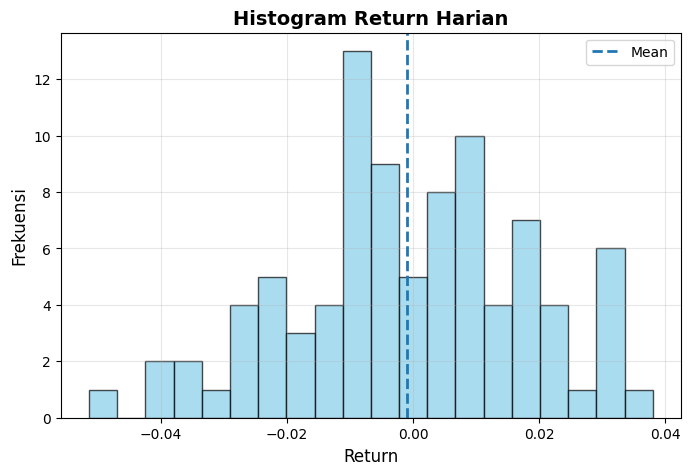

In [32]:
plt.figure(figsize=(8,5))
plt.hist(returns, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(returns), linestyle='dashed', linewidth=2, label='Mean')
plt.title('Histogram Return Harian', fontsize=14, fontweight='bold')
plt.xlabel('Return', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Berdasarkan histogram diatas menunjukkan bahwa return harian saham berdistribusi mendekati normal dengan nilai rata-rata mendekati nol (sedikit positif). Sebagian besar return berada di sekitar nilai kecil, namun terdapat penyebaran yang cukup lebar. Jadi, pergerakan saham cenderung acak dan fluktuatif, dengan peluang keuntungan dan kerugian yang relatif seimbang, serta risiko yang cukup tinggi akibat variasi return yang besar.